In [4]:
!pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.9 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.9 MB 2.0 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.0 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.9 MB 2.0 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/9.9 MB 2.1 MB/s eta 0:00:04
   --------------- ------------------------ 3.9/9.9 MB 2.1 MB/s eta 0:00:03
   ---------------- ----------------------- 4.2/9.9 MB 2.1 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.9 MB 2.1 MB/s eta 0:00:03
   --------------------- --------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [26]:
# Check the number of rows and columns
print(f"Dataset shape (rows, columns): {df.shape}")

# Check for any missing values and data types
df.info()

Dataset shape (rows, columns): (1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


In [27]:
# Select only relevant numeric columns as Features (X)
X = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]

# Set the categorical product column as Target (y)
y = df['Product']

print("Top rows of Features (X):")
print(X.head())

Top rows of Features (X):
   Quantity  UnitPrice  ItemsInCart  TotalPrice
0         5     570.62            7     2853.10
1         2     151.35            3      302.70
2         5     550.68            8     2753.40
3         1     273.19            5      273.19
4         4     626.01            8     2504.04


In [11]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 873.4 kB/s eta 0:00:09
   -- ------------------------------------- 0.5/8.3 MB 873.4 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.3 MB 870.3 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.3 MB 870.3 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 841.3 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 878.9 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.3 MB 904.3 kB/s eta 0:00:08
   -------- ------------------------------- 1.8/8.3 MB 922.2 kB/s eta 0:00:08
   ---------- ----------------------------- 2.1/8.3 MB 925.6 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.3 MB 925.6 kB/s eta 0:00:07
   ----------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Data split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. KNN Model (K=5)
model = KNeighborsClassifier(n_neighbors=5)

# 3. Train model
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Accuracy check
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy of model is: {accuracy * 100:.2f}%")

Classification Accuracy of model is: 10.83%


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Split the data into Features (X) and Target (y)
X = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]
y = df['Product']

# 2. Split the data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create the KNN Classifier Model (with K=5)
model = KNeighborsClassifier(n_neighbors=5)

# 4. Train (fit) the model on the training data
model.fit(X_train, y_train)

# 5. Make predictions on the test data
y_pred = model.predict(X_test)

# 6. Calculate and print the final accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Classification Accuracy is: {accuracy * 100:.2f}%")

Model Classification Accuracy is: 10.83%


In [15]:
# K=11 
model_new = KNeighborsClassifier(n_neighbors=11)
model_new.fit(X_train, y_train)
y_pred_new = model_new.predict(X_test)

print(f"Nayi Accuracy: {accuracy_score(y_test, y_pred_new) * 100:.2f}%")

Nayi Accuracy: 12.92%


In [24]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


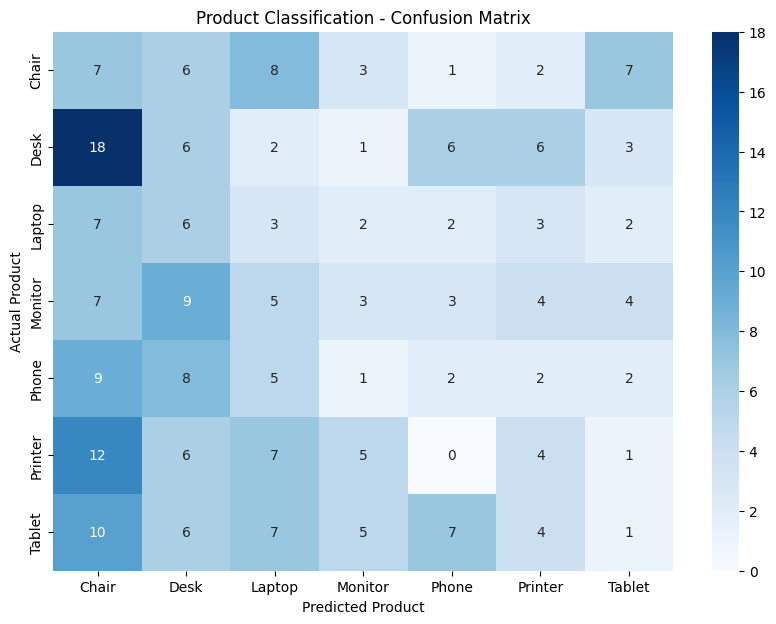

In [25]:
# 1. Jupyter ke graphics backend ko inline rendering par force karein
%matplotlib inline

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# 2. File read karne ke liye safe check path configuration
file_name = 'Dataset for Data Analytics - Sheet1.csv'
paths_to_check = [file_name, os.path.join(os.getcwd(), file_name)]
df = None

for path in paths_to_check:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break

if df is None:
    # Agar local folder se na mile toh fallback to default user path
    df = pd.read_csv(r'C:\Users\Zainab\Downloads\Dataset for Data Analytics - Sheet1.csv')

# 3. Features aur Target split
X = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]
y = df['Product']

# 4. Train Test Split & Model Fitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Confusion Matrix Structure Calculation
cm = confusion_matrix(y_test, y_pred)

# 6. Graph Configuration (Ab error nahi aayega kyunki matplotlib reset ho gaya hai)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_, ax=ax)

ax.set_title('Product Classification - Confusion Matrix')
ax.set_xlabel('Predicted Product')
ax.set_ylabel('Actual Product')

# Graphics display execution
plt.show()